---------------

Natural language:
Project:15
Student Name:
Kushal Panthi,
Aavash Neupane,
Siddharth Pudasini,
Suraj

In [3]:
!pip install numpy
!pip install matplotlib
!pip install pandas
!pip install seaborn
!pip install scikit-learn


---------------

Imoporting Libraries

In [6]:
import numpy as np #Numerical operations, arrays, and matrices
import pandas as pd #Data manipulation

Creating/Loading datasets

In [8]:
data_real = pd.read_csv('datasets/orginal/BuzzFeed_real_news_content.csv') #for the real data sets
print ("Real news ", data_real.shape)
data_fake = pd.read_csv('datasets/orginal/BuzzFeed_fake_news_content.csv') #for the real data sets
print ("Fake news", data_fake.shape)

Real news  (91, 12)
Fake news (91, 12)


Combining both the data sets

In [10]:
data_news = pd.concat([data_real, data_fake], axis =0) #concatinating the data sets
print("Combined: ", data_news.shape)



Combined:  (182, 12)


In [11]:
import os
os.makedirs('datasets/changed', exist_ok=True)
data_news.to_csv('datasets/changed/data_news.csv', index=False)

Extract news type from 'id' column and store in 'type_of_news'.

Drop the 'id' column.

Move 'type_of_news' to the first column.

In [13]:
import pandas
def extract_type_of_news(news_id):
    # Extracts the type of news from the given ID string
    if isinstance(news_id, str) and '_' in news_id:
        return news_id.split('_')[0]
    return news_id  # Return as is if not a valid format

# Apply the function to create the 'type_of_news' column
data_news['type_of_news'] = data_news['id'].apply(extract_type_of_news)

# Drop the 'id' column
data_news.drop(columns=['id'], inplace=True)

# Move 'type_of_news' to the first column
cols = ['type_of_news'] + [col for col in data_news.columns if col != 'type_of_news']
data_news = data_news[cols]

print(data_news.columns)

Index(['type_of_news', 'title', 'text', 'url', 'top_img', 'authors', 'source',
       'publish_date', 'movies', 'images', 'canonical_link', 'meta_data'],
      dtype='object')


In [14]:
data_news.head(2)

,type_of_news,title,text,url,top_img,authors,source,publish_date,movies,images,canonical_link,meta_data
0,Real,Another Terrorist Attack in NYC…Why Are we STI...,"On Saturday, September 17 at 8:30 pm EST, an e...",http://eaglerising.com/36942/another-terrorist...,http://eaglerising.com/wp-content/uploads/2016...,"View All Posts,Leonora Cravotta",http://eaglerising.com,{'$date': 1474528230000},NaN,http://constitution.com/wp-content/uploads/201...,http://eaglerising.com/36942/another-terrorist...,"{""description"": ""\u201cWe believe at this poin..."
1,Real,"Donald Trump: Drugs a 'Very, Very Big Factor' ...",Less than a day after protests over the police...,http://abcn.ws/2d4lNn9,http://a.abcnews.com/images/Politics/AP_donald...,"More Candace,Adam Kelsey,Abc News,More Adam",http://abcn.ws,NaN,NaN,http://www.googleadservices.com/pagead/convers...,http://abcnews.go.com/Politics/donald-trump-dr...,"{""fb_title"": ""Trump: Drugs a 'Very, Very Big F..."


In [15]:
print("After adding type_of_news and substituting it with id column:", data_news.shape)

After adding type_of_news and substituting it with id column: (182, 12)


In [16]:
# Summary of dataframe structure and data types
data_news.info()

<class 'pandas.core.frame.DataFrame'>
Index: 182 entries, 0 to 90
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   type_of_news    182 non-null    object
 1   title           182 non-null    object
 2   text            182 non-null    object
 3   url             174 non-null    object
 4   top_img         172 non-null    object
 5   authors         141 non-null    object
 6   source          174 non-null    object
 7   publish_date    133 non-null    object
 8   movies          25 non-null     object
 9   images          172 non-null    object
 10  canonical_link  170 non-null    object
 11  meta_data       182 non-null    object
dtypes: object(12)
memory usage: 18.5+ KB


In [17]:
# descriptive statistics for numerical columns
data_news.describe()

,type_of_news,title,text,url,top_img,authors,source,publish_date,movies,images,canonical_link,meta_data
count,182,182,182,174,172,141,174,133,25,172,170,182
unique,2,178,178,171,166,90,28,118,25,169,168,171
top,Real,CNN’s Post-Debate Rigged Poll Busted…Here Are ...,We’re shocked — SHOCKED — to learn that CNN’s ...,http://eaglerising.com/36847/clinton-foundatio...,http://static.politico.com/da/f5/44342c424c68b...,Terresa Monroe-hamilton,http://politi.co,{'$date': 1474588800000},https://www.youtube.com/embed/ji6pl5Vwrvk,http://static.politico.com/da/f5/44342c424c68b...,http://eaglerising.com/36847/clinton-foundatio...,{}
freq,91,2,2,2,3,8,32,5,1,2,2,8


---------------

Data Cleaning and Freature Engineering

---------------

We retain relevant columns and remove unnecessary columns.

In [22]:
data_news.drop(['url', 'top_img', 'authors', 'publish_date', 'movies', 'images', 'canonical_link', 'meta_data'], axis=1, inplace=True)

In [23]:
print("After dropping unnecessary columns:\n ")
data_news.describe()

After dropping unnecessary columns:
 


,type_of_news,title,text,source
count,182,182,182,174
unique,2,178,178,28
top,Real,CNN’s Post-Debate Rigged Poll Busted…Here Are ...,We’re shocked — SHOCKED — to learn that CNN’s ...,http://politi.co
freq,91,2,2,32


In [24]:
# Displaying count of missing values for each column
data_news.isnull().sum()

type_of_news    0
title           0
text            0
source          8
dtype: int64

In [25]:
# Calculate percentage of missing values for each column in the data
(data_news.isnull().sum() / data_news.shape[0]) * 100

type_of_news    0.000000
title           0.000000
text            0.000000
source          4.395604
dtype: float64

In [26]:
data_news.head(2)

,type_of_news,title,text,source
0,Real,Another Terrorist Attack in NYC…Why Are we STI...,"On Saturday, September 17 at 8:30 pm EST, an e...",http://eaglerising.com
1,Real,"Donald Trump: Drugs a 'Very, Very Big Factor' ...",Less than a day after protests over the police...,http://abcn.ws


---------------

Data Analysis (Real News vs Fake News)

---------------

Analyzing news based on Source:

Sources of Publishing Real News

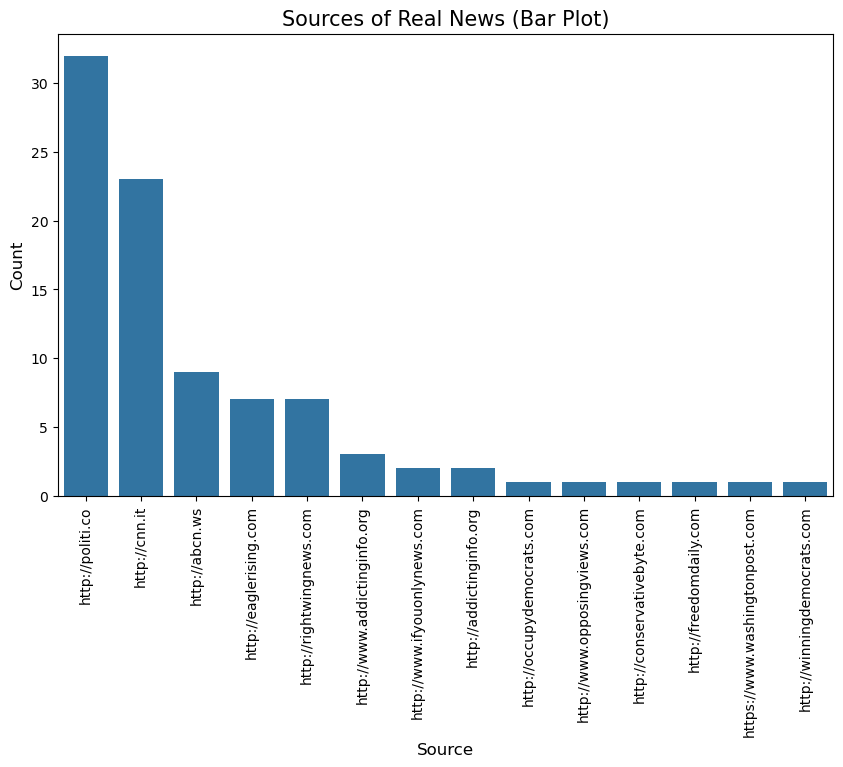

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# analyzing sources
real_news = data_news[data_news['type_of_news'] == 'Real']
real_news_order = real_news['source'].value_counts().index

# plotting sources
# Bar plot for real news sources
plt.figure(figsize=(10, 6))
sns.barplot(x=real_news_order, y=real_news['source'].value_counts().sort_values(ascending=False))
plt.xlabel('Source', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Sources of Real News (Bar Plot)', fontsize=15)
plt.xticks(rotation=90)
plt.show()

Observations:

'politi.co' reports most Real news

'winningdemocrats.com' reports least Real news

---------------

Sources of Publishing Fake News

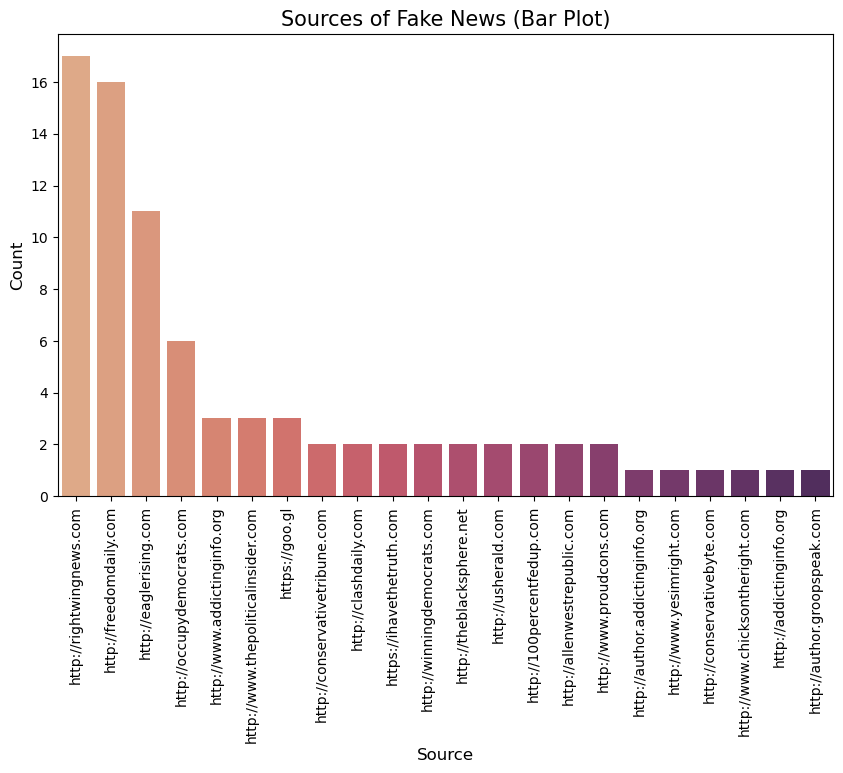

In [41]:
# Import necessary libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Analyzing sources
fake_news = data_news[data_news['type_of_news'] == 'Fake']
fake_news_counts = fake_news['source'].value_counts()
fake_news_order = fake_news_counts.index

# Plotting sources
plt.figure(figsize=(10, 6))
sns.barplot(x=fake_news_order, y=fake_news_counts, hue=fake_news_order, palette='flare', legend=False)
plt.xlabel('Source', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Sources of Fake News (Bar Plot)', fontsize=15)
plt.xticks(rotation=90)
plt.show()


Observations:

'rightwingnews.com' reports most Fake news

'author.groopspeak.com' reports least Fake news

---------------

Common Sources of Publishing both Real and Fake News

In [ ]:
fake_sources = set(data_news[data_news['type_of_news'] == 'Fake']['source'].unique())
real_sources = set(data_news[data_news['type_of_news'] == 'Real']['source'].unique())

common_sources = list(fake_sources & real_sources)
sum_common_sources = len(common_sources)
print("List of common sources are:\n ", common_sources)
print("\nNumber of Common Sources: ", sum_common_sources)

In [ ]:
# Identifying common sources
common_sources = set(data_news[data_news['type_of_news'] == 'Fake']['source']).intersection(
    set(data_news[data_news['type_of_news'] == 'Real']['source']))

# Filter the dataframe for common sources
common = data_news[data_news['source'].isin(common_sources)]

# Plotting the count of common sources by news type
plt.figure(figsize=(10, 6))
sns.barplot(x='source', y='count', data=common.groupby(['source', 'type_of_news']).size().reset_index(name='count'), hue='type_of_news', palette='viridis')
plt.xlabel('Source', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(loc='best', title='News Type', fontsize=10)
plt.title('Common Sources of Real and Fake News', fontsize=20)
plt.xticks(rotation=90)
plt.show()



From the graph, it is clear that some sources are more commonly associated with fake news than real news. For instance, http://freedomdaily.com and http://rightwingnews.com have significantly higher counts of fake news compared to real news, with http://rightwingnews.com having the highest number of fake news entries.

On the other hand, sources like http://conservativebyte.com and http://www.addictinginfo.org show a more balanced distribution between real and fake news.

Sources like http://conservativebyte.com, http://addictinginfo.org, and http://winningdemocrats.com have relatively low counts of both real and fake news.

Notably, http://freedomdaily.com, http://occupydemocrats.com, and http://rightwingnews.com have a noticeable gap where fake news dominates over real news.

This suggests that certain sources tend to be more biased toward fake news, while others show a more mixed or balanced profile.

---------------

In [ ]:
print(data_news.head())

In [ ]:
os.makedirs('datasets/changed', exist_ok=True)
data_news.to_csv('datasets/changed/data_news_features.csv', index=False)

---------------

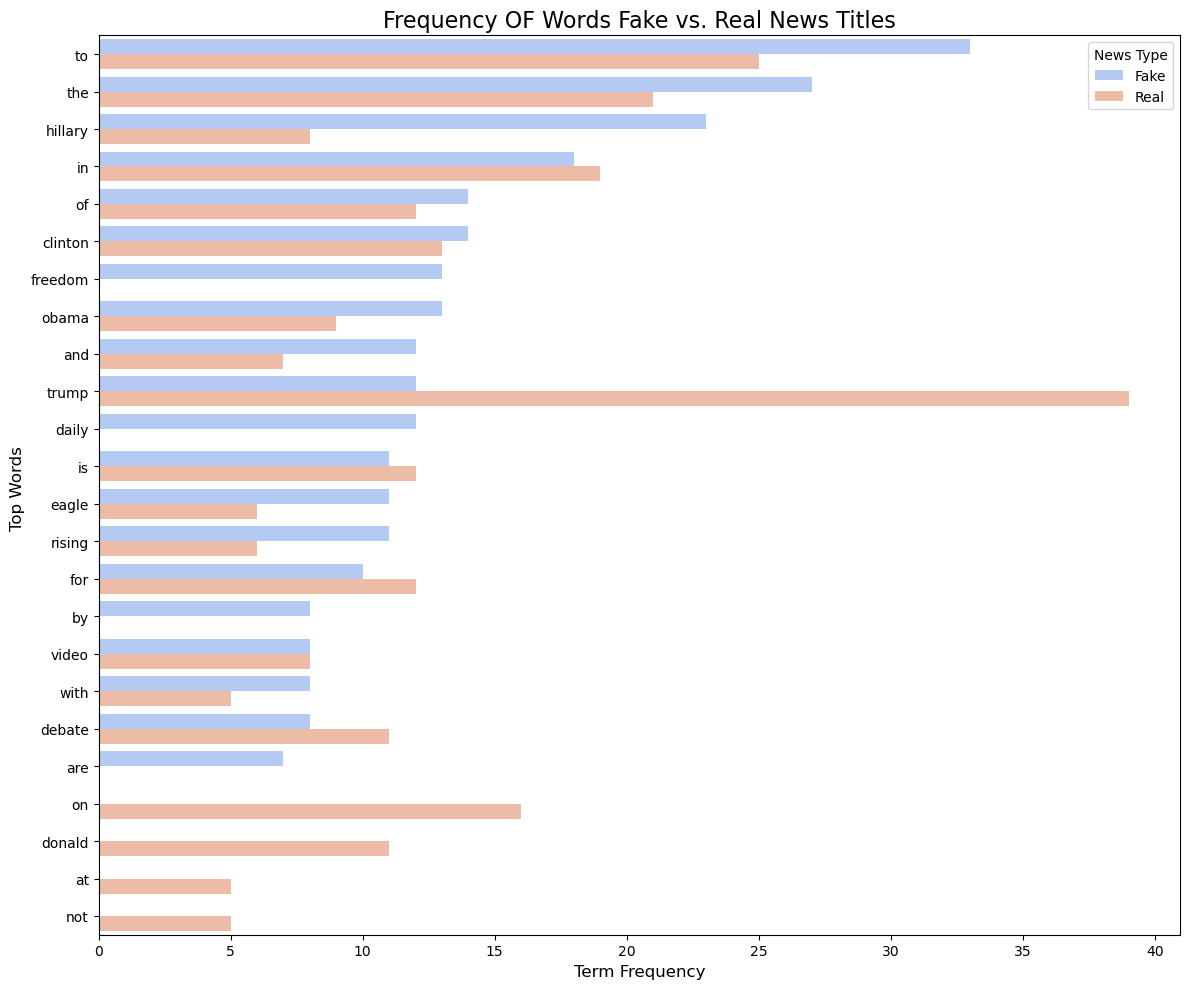

In [66]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
import seaborn as sns
import matplotlib.pyplot as plt



def get_top_words(df_subset, label, top_n=20):
    vectorizer = CountVectorizer()
    bow = vectorizer.fit_transform(df_subset['title'].astype(str))

    # Get word frequencies
    word_freq = bow.sum(axis=0).A1
    words = vectorizer.get_feature_names_out()

    # Create DataFrame with word frequencies
    word_df = pd.DataFrame({'word': words, 'frequency': word_freq})
    word_df = word_df.sort_values(by='frequency', ascending=False).head(top_n)
    word_df['news_type'] = label
    return word_df

# Fix: Assuming these are already filtered DataFrames
# If not, filter from a full DataFrame like: data_news[data_news['news_type'] == 'Fake']
top_fake = get_top_words(data_fake, 'Fake')
top_real = get_top_words(data_real, 'Real')

# Combine and plot
top_words = pd.concat([top_fake, top_real])

plt.figure(figsize=(12, 10))
sns.barplot(
    data=top_words,
    y='word',
    x='frequency',
    hue='news_type',  # Fix: match the correct column name
    palette='coolwarm'
)
plt.xlabel('Term Frequency', fontsize=12)
plt.ylabel('Top Words ', fontsize=12)
plt.title('Frequency OF Words Fake vs. Real News Titles', fontsize=16)
plt.legend(title='News Type')
plt.tight_layout()
plt.show()
